In [1]:
import numpy as np

import pickle

from benchmark_utils import laplacian, norm_laplacian
from benchmark_distances import distance_frobenius, distance_procrustes_LE
import benchmark_methods

import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix

import compute_S_rate

Could not load cython functions. Some functionality might be broken.
Could not load sparse_dot_mkl. Will use scipy.sparse for matrix products.


In [7]:
aggregation_window = 10

In [5]:
with open('block2activities_snapshots.pkl', 'rb') as handle:
    tnet = pickle.load(handle)
    net = tnet['net']
    snapshots = tnet['snapshots']
    t_split = tnet['t_split']

In [ ]:
t_split

In [ ]:
def avg_frobenius_distance(data, window_length, diff=False):
    """
    Computes averaged Frobenius distance statistics over a backward window

    :param data:
    :param window_length:
    :return:
    """

    if not isinstance(data[0], np.ndarray):
        data = [data[i].toarray() for i in range(len(data))]

    avg_dist = []
    for i in range(window_length, len(data)):
        dist_t = []
        for j in range(1, window_length + 1):
            dist_t.append(distance_frobenius(data[i], data[i - j]))
        avg_dist.append( np.mean(dist_t) )

    if diff:
        d_avg_dist = np.abs(np.array(avg_dist[1:]) - np.array(avg_dist[:-1]))
        return d_avg_dist, np.arange(window_length+1, len(data))

    return np.array(avg_dist), np.arange(window_length, len(data))

In [ ]:
frob_dist, t_frob = avg_frobenius_distance(snapshots, window_length=5)

In [ ]:
plt.plot(range(frob_dist.shape[0]), frob_dist)

## CUMSUM 2

In [ ]:
stat, t = benchmark_methods.CUMSUM_2([csr_matrix(s)for s in snapshots], window_length=1)

In [ ]:
len(stat)

In [ ]:
plt.plot(t, stat, alpha=1)

## Entropy Method

In [12]:
p0 = np.ones(net.num_nodes) / net.num_nodes
S_vals = [0.0]  # if you want the same convention as before

on_T = compute_S_rate.make_on_window_matrix_entropy_callback(p0, S_vals)

net.compute_laplacian_matrices(
                t_start=net.times[0],
                t_stop=net.times[-1],
                random_walk=False,
            )


lamda = 0.1

net.compute_inter_transition_matrices(
            lamda=lamda,
            t_start=net.times[0],
            t_stop=net.times[-1],
            dense_expm=False,
            use_sparse_stoch=False,
            random_walk=False,
        )

net.compute_transition_matrices_sliding_timewindow(
    lamda=lamda,
    window_timelength=aggregation_window / 2,
    save_intermediate=False,   # <- important: do NOT store matrices
    on_window_matrix=on_T,     # <- compute/store only entropy scalars
    force_csr=True,
)

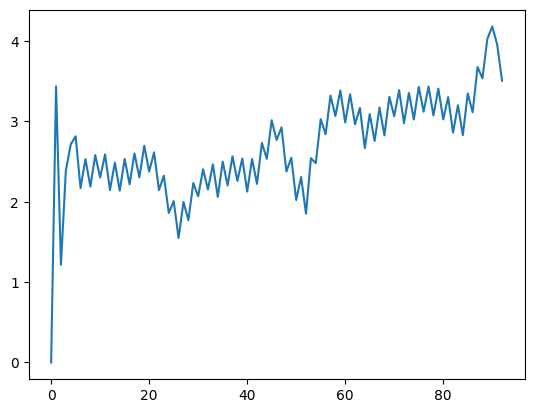

In [13]:
plt.plot(range(len(S_vals)), S_vals)

### Lin Inter Transition Matrices

In [2]:
with open('block2activities_snapshots.pkl', 'rb') as handle:
    tnet = pickle.load(handle)
    net_lin = tnet['net']
    snapshots = tnet['snapshots']
    t_split = tnet['t_split']

In [3]:
p0 = np.ones(net_lin.num_nodes) / net_lin.num_nodes
S_vals_lin = [0.0]  # if you want the same convention as before

on_T = compute_S_rate.make_on_window_matrix_entropy_callback(p0, S_vals_lin)

net_lin.compute_laplacian_matrices(
                t_start=net.times[0],
                t_stop=net.times[-1],
                random_walk=False,
            )


lamda = 0.001

net_lin.compute_lin_inter_transition_matrices(
            lamda=lamda,
            t_start=net.times[0],
            t_stop=net.times[-1],
            use_sparse_stoch=False,
        )

net_lin.compute_transition_matrices_sliding_timewindow(
    lamda=lamda,
    window_timelength=aggregation_window / 2,
    save_intermediate=False,   # <- important: do NOT store matrices
    on_window_matrix=on_T,     # <- compute/store only entropy scalars
    force_csr=True,
)

NameError: name 'net' is not defined

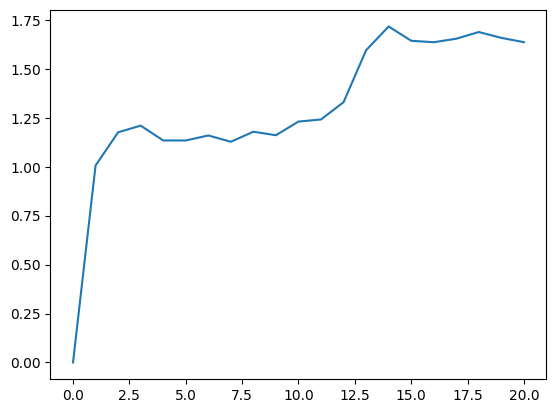

In [7]:
plt.plot(range(len(S_vals_lin)), S_vals_lin)